### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [98]:
# Data Loading
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.dropna(inplace=True)
wine.drop_duplicates(inplace=True)
wine.head(5)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,white,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


In [99]:
X=wine.iloc[:,1:].values
y=wine.iloc[:,0].values

In [100]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [101]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [112]:
KNN=KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train,y_train)
y_pred=KNN.predict(X_test)
print('KNN features =',12)
print('accuracy_score without PCA =',accuracy_score(y_test,y_pred))

KNN features = 12
accuracy_score without PCA = 0.9933899905571294


In [103]:
pca=PCA(n_components=6)
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [95]:
KNN=KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train_trf,y_train)
y_pred=KNN.predict(X_test_trf)
print(accuracy_score(y_pred,y_test))

0.9886685552407932


In [117]:
accuracy=[]
for i in range(1,13):
  pca=PCA(n_components=i)
  X_train_trf=pca.fit_transform(X_train)
  X_test_trf=pca.transform(X_test)
  KNN=KNeighborsClassifier(n_neighbors=5)
  KNN.fit(X_train_trf,y_train)
  y_pred=KNN.predict(X_test_trf)
  accuracy.append(accuracy_score(y_pred,y_test))
  print('KNN features =',i)
  print('accuracy_score with PCA =',accuracy_score(y_test,y_pred))

KNN features = 1
accuracy_score with PCA = 0.9754485363550519
KNN features = 2
accuracy_score with PCA = 0.9763928234183191
KNN features = 3
accuracy_score with PCA = 0.9754485363550519
KNN features = 4
accuracy_score with PCA = 0.9858356940509915
KNN features = 5
accuracy_score with PCA = 0.9886685552407932
KNN features = 6
accuracy_score with PCA = 0.9886685552407932
KNN features = 7
accuracy_score with PCA = 0.9905571293673276
KNN features = 8
accuracy_score with PCA = 0.9933899905571294
KNN features = 9
accuracy_score with PCA = 0.9924457034938622
KNN features = 10
accuracy_score with PCA = 0.9924457034938622
KNN features = 11
accuracy_score with PCA = 0.9924457034938622
KNN features = 12
accuracy_score with PCA = 0.9933899905571294


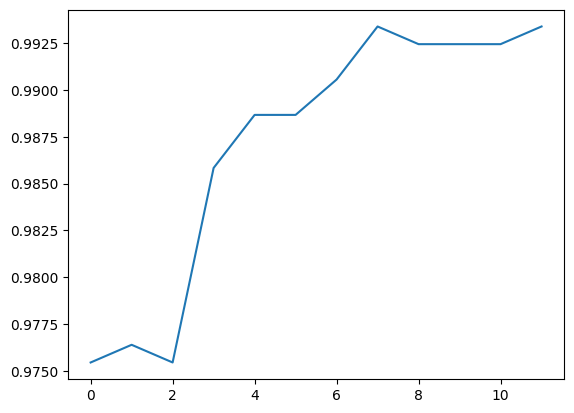

In [116]:
import matplotlib.pyplot as plt
plt.plot(accuracy)